In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

### Imports

In [2]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from utils.metrics import get_spatial_correlation

import scipy
import pandas as pd
import numpy as np
import os
import yaml
import matplotlib.pyplot as plt

# Processed data for the Science and Muessig papers

### Parameters

In [3]:
from utils.spatial_units import RateMaps, PolarMaps

N_SAMPLES_POS = RateMaps.N_SAMPLES_POS
PLACE_SI_TH = RateMaps.PLACE_SI_TH

N_SAMPLES_THET = PolarMaps.N_SAMPLES_THET
HD_SI_TH = PolarMaps.HD_SI_TH
HD_RVL_TH = PolarMaps.HD_RVL_TH


In [ ]:
edge_n_bins = 4

ONLY_2ND_TRIAL = True

AGES_TO_REMOVE = list(range(26, 32 +1))

SAVE_PLOTS = False
SAVE_DIR = None

### Load Data

In [5]:
ratnames_science = []
ratnames_muessig = []

data_dir = os.path.join(DATA_DIR, 'real_data', 'science2010_data_struct')
data = {}
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_science2010'
        else:
            ratnames_science.append(name)
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

data_dir = os.path.join(DATA_DIR, 'real_data', 'muessig_data_struct')
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_muessig'
        else:
            ratnames_muessig.append(name)
            
        if name in data.keys():
            raise ValueError(f"Duplicate file name: {name}")
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

sorted(list(data.keys()))[:5]

['r101_p20', 'r104_p26', 'r112_p40', 'r115_p24', 'r118_p24']

In [6]:
def get(x):
    return x[0][0]

data_dict = {}
ratnames_old = []

for k in data.keys():
    print(k)

    if not k.startswith('r'):
        print(f"File name {k} does not start with 'r', skipping")
        continue

    ratname = k
    
    if ratname not in data_dict.keys():
        data_dict[ratname] = {}
    
    d = get(data[k]['tmpS'])
    d_keys = list(d.dtype.names)

    dataset = d[d_keys.index('dataset')][0].split('_')[-1]
    ratnames_old.append(f"{ratname}_{dataset}")

    # sample rate is always 50 Hz
    ages = d[d_keys.index('age')][0] # age 40 denotes adult
    ages = [a if a<100 else 40 for a in ages]

    sample_rates = d[d_keys.index('sampleRate')][0]
    env_types = d[d_keys.index('envType')][0]
    ppm = d[d_keys.index('ppm')][0]
    spike_times = d[d_keys.index('spikeTimes')][0]
    is_cs_neuron = d[d_keys.index('isCSNeuron')][0]
    has_min_freq = d[d_keys.index('hasMinFreq')][0]
    pos = d[d_keys.index('positions')][0]
    hd = d[d_keys.index('directions')][0] # degrees
    speed = d[d_keys.index('speed')][0] # cm/s

    rate_maps = d[d_keys.index('rateMaps')][0]
    pos_occ = d[d_keys.index('posOccMaps')][0]
    si = d[d_keys.index('SI')][0]
    rate_maps_corr = d[d_keys.index('corrRateMaps')][0]
    si_corr = d[d_keys.index('SICorr')][0]
    rate_maps_hd8 = d[d_keys.index('rateMapsHD8')][0]
    rate_maps_hd4 = d[d_keys.index('rateMapsHD4')][0]
    
    polar_maps = d[d_keys.index('polarMaps')][0]
    si_pm = d[d_keys.index('dirSI')][0]
    rvl = d[d_keys.index('rvLength')][0]
    hd_occ = d[d_keys.index('dirOccMaps')][0]
    polar_maps_corr = d[d_keys.index('corrPolarMaps')][0]
    si_pm_corr = d[d_keys.index('dirSICorr')][0]
    rvl_corr = d[d_keys.index('rvLengthCorr')][0]
    polar_maps_pred = d[d_keys.index('predPolarMaps')][0]
    dis_ratios = d[d_keys.index('disRatios')][0]

    # there are always max 3 trials per day
    n_trials = 0
    for trial_n in range(len(ages)):
        if ONLY_2ND_TRIAL and (trial_n != 1) : continue # keep second trial

        rms = rate_maps[trial_n]
        sis = si[trial_n]
        rms_corr = rate_maps_corr[trial_n]
        sis_corr = si_corr[trial_n]
        rms_hd8 = rate_maps_hd8[trial_n]
        rms_hd4 = rate_maps_hd4[trial_n]

        pms = polar_maps[trial_n]
        sis_pm = si_pm[trial_n]
        rvls = rvl[trial_n]
        pms_corr = polar_maps_corr[trial_n]
        sis_pm_corr = si_pm_corr[trial_n]
        rvls_corr = rvl_corr[trial_n]
        drs = dis_ratios[trial_n]
        pms_pred = polar_maps_pred[trial_n]
        if rms.shape[-1] == 0 or pms.shape[-1] == 0:
            print(f"Skipping trial {trial_n} because rate maps or polar maps are empty")
            continue

        t = {}
        age = ages[trial_n]
        env = env_types[trial_n][0]
        p = pos[trial_n]
    
        if np.isnan(age) and (len(env) == 0) and (p.shape[-1] == 0):
            continue
        n_trials += 1

        age = int(age)
        if age not in data_dict[ratname].keys():
            data_dict[ratname][age] = {}
            data_dict[ratname][age]['trials'] = []

        t['name'] = n_trials
        t['environment'] = env
        t['ppm'] = ppm
        t['sample_rate'] = sample_rates[trial_n] # Hz
        t['positions'] = p
        t['x'] = p[:,0]
        t['y'] = p[:,1]
        if ratname in ratnames_science:
            t['spike_times'] = spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n][0]
        else:
            t['spike_times'] = spike_times[trial_n].squeeze() if len(spike_times[trial_n])>1 else spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n].squeeze() if len(is_cs_neuron[trial_n])>1 else is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n].squeeze() if len(has_min_freq[trial_n])>1 else has_min_freq[trial_n][0]

        t['speed'] = speed[trial_n].squeeze()/100 # m/s
        t['hd'] = hd[trial_n].squeeze()
        t['duration'] = len(t['x'])/t['sample_rate']

        # convert to (n_units, n_bins, n_bins)
        t['rate_maps'] = np.array([rms[idx][0] for idx in range(len(rms))])
        t['si'] = np.array([sis[idx][0] for idx in range(len(sis))])
        t['rate_maps_corr'] = np.array([rms_corr[idx][0] for idx in range(len(rms_corr))])
        t['si_corr'] = np.array([sis_corr[idx][0] for idx in range(len(sis_corr))])

        rms_hd_np8 = np.zeros((t['rate_maps'].shape[0], 8, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        rms_hd_np4 = np.zeros((t['rate_maps'].shape[0], 4, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        for j in range(8):
            if j < 4:
                rms_hd_np4[:, j, ...] = np.array(
                    [get(rms_hd4[idx])[j] for idx in range(len(rms_hd4))]
                )
            rms_hd_np8[:, j, ...] = np.array(
                [get(rms_hd8[idx])[j] for idx in range(len(rms_hd8))]
            )
        # convert to (n_units, 8, n_bins, n_bins)
        t['rate_maps_hd8'] = rms_hd_np8
        t['rate_maps_hd4'] = rms_hd_np4

        # convert to (n_units, n_bins)
        t['polar_maps'] = np.array([pms[idx][0] for idx in range(len(pms))])[..., 0]
        t['si_pm'] = np.array([sis_pm[idx][0] for idx in range(len(sis_pm))])
        t['rvl'] = np.array([rvls[idx][0] for idx in range(len(rvls))])
        t['polar_maps_corr'] = np.array([pms_corr[idx][0] for idx in range(len(pms_corr))])[..., 0]
        t['si_pm_corr'] = np.array([sis_pm_corr[idx][0] for idx in range(len(sis_pm_corr))])
        t['rvl_corr'] = np.array([rvls_corr[idx][0] for idx in range(len(rvls_corr))])

        t['polar_maps_pred'] = np.array([pms_pred[idx][0] for idx in range(len(pms_pred))])[..., 0]
        t['dis_ratios'] = np.array(drs[:,0])

        if t['rate_maps'].shape[0] != t['polar_maps'].shape[0]:
            raise ValueError(f"Rate maps ({t['rate_maps'].shape}) and polar maps ({t['polar_maps'].shape}) have different number of units")

        t['pos_occ'] = get(pos_occ[trial_n])
        t['hd_occ'] = np.array(hd_occ[trial_n][:,0])

        data_dict[ratname][age]['trials'].append(t)
    print(f"\t{n_trials} trial(s)")
    print()

r1308_d4
	1 trial(s)

r1526_p18
	1 trial(s)

r1343_d4
	1 trial(s)

r1526_p23
	1 trial(s)

r1343_d1
	1 trial(s)

r1589_p22
	1 trial(s)

r1589_p28
	1 trial(s)

r1333_d1
	1 trial(s)

r1477_p29
	1 trial(s)

r1552_p22
	1 trial(s)

r1637_p23
	1 trial(s)

r1588_p20
	1 trial(s)

r1589_p23
	1 trial(s)

r1589_p27
	1 trial(s)

r1588_p22
	1 trial(s)

r1515_p23
	1 trial(s)

r1589_p17
	1 trial(s)

r1589_p26
	1 trial(s)

r1552_p17
	1 trial(s)

r1308_d1
	1 trial(s)

r1526_p20
	1 trial(s)

r1589_p21
	1 trial(s)

r1552_p16_1
	1 trial(s)

r1589_p25
	1 trial(s)

r1333_d2
	1 trial(s)

r1628_p22_ca1
	1 trial(s)

r1589_p19
	1 trial(s)

r1515_p22
	1 trial(s)

r1526_p21
	1 trial(s)

r1588_p24
	1 trial(s)

r1474_p25
	1 trial(s)

r1552_p16_2
	1 trial(s)

r1588_p16
	1 trial(s)

shuffled_metrics_science2010
File name shuffled_metrics_science2010 does not start with 'r', skipping
shuffled_metrics_adult_science2010
File name shuffled_metrics_adult_science2010 does not start with 'r', skipping
r1588_p21
	1 trial(s)



In [7]:
ages = []
print('--------------------------------')
for k, v in data_dict.items():
    print(k)
    ages_tmp = list(v.keys())
    print('ages', ages_tmp)
    ages += ages_tmp
    print()
    print('--------------------------------')

--------------------------------
r1308_d4
ages [40]

--------------------------------
r1526_p18
ages [18]

--------------------------------
r1343_d4
ages [40]

--------------------------------
r1526_p23
ages [23]

--------------------------------
r1343_d1
ages [40]

--------------------------------
r1589_p22
ages [22]

--------------------------------
r1589_p28
ages [28]

--------------------------------
r1333_d1
ages [40]

--------------------------------
r1477_p29
ages [29]

--------------------------------
r1552_p22
ages [22]

--------------------------------
r1637_p23
ages [23]

--------------------------------
r1588_p20
ages [20]

--------------------------------
r1589_p23
ages [23]

--------------------------------
r1589_p27
ages [27]

--------------------------------
r1588_p22
ages [22]

--------------------------------
r1515_p23
ages [23]

--------------------------------
r1589_p17
ages [17]

--------------------------------
r1589_p26
ages [26]

--------------------------------

### Shuffled Threshold Extraction

In [8]:
metrics_shuffle_th_science = {}
metrics_shuffle_th_muessig = {}

for filename in data.keys():
    if not filename.startswith('shuffled'):
        continue
    print(filename)

    shuffled_si = data[filename]['shuffledSIByAge']
    shuffled_si_pm = data[filename]['shuffledDirSIByAge']
    shuffled_rvl = data[filename]['shuffledRVLByAge']
    for idx in range(len(shuffled_si)):
        for m, k in zip([shuffled_si, shuffled_si_pm, shuffled_rvl], ['SI', 'dirSI', 'rvLength']):
            m_curr = get(m[idx][0])
            keys = list(m_curr.dtype.names)
            age_group = get(m_curr[keys.index('ageGroup')])
            th = get(m_curr[keys.index(k+'Threshold')])

            if 'science' in filename.lower():
                if k not in metrics_shuffle_th_science.keys():
                    metrics_shuffle_th_science[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_science[k][age] = th
                    metrics_shuffle_th_science[k][age+1] = th
                else : metrics_shuffle_th_science[k][40] = th
            elif 'muessig' in filename.lower():
                if k not in metrics_shuffle_th_muessig.keys():
                    metrics_shuffle_th_muessig[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_muessig[k][age] = th
                    metrics_shuffle_th_muessig[k][age+1] = th
                else : metrics_shuffle_th_muessig[k][40] = th


shuffled_metrics_science2010
shuffled_metrics_adult_science2010
shuffled_metrics_muessig


### Activity Extraction

A neuron is considered actually tuned to direction if its corrected polar map still passes the criterion for inclusion (RVL or KLD)

and its Pearson correlation with the uncorrected polar map is higher than 0.5

In [9]:
def normalize_rate_maps(rate_maps):
    # normalize rate maps
    rate_maps_min = np.moveaxis(
        np.tile(np.nanmin(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps_max = np.moveaxis(
        np.tile(np.nanmax(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps = (
        (rate_maps - rate_maps_min) / (rate_maps_max - rate_maps_min)
    )
    return rate_maps

In [10]:
from utils.spatial_units import RateMaps, PolarMaps

place_units = RateMaps(positions=None, env_dim=0)
hd_units = PolarMaps(thetas=None)

data_dict_age = {}
perc_kept = []

for k, v in sorted(data_dict.items()):
    print(f"Rat {k}")
    if k in ratnames_science:
        metrics_shuffle_th = metrics_shuffle_th_science
    elif k in ratnames_muessig:
        metrics_shuffle_th = metrics_shuffle_th_muessig
    else:
        raise ValueError(f"Rat {k} not found in science or muessig data")
    
    for age in sorted(v.keys()):
        if age in AGES_TO_REMOVE:
            print(f"\tAge {age} in ages to remove, skipping")
            continue
        
        exp = v[age] # get the experiment for this rat's age
        print(f"\tAge {age}")
        if (age in data_dict_age.keys()) and (k in data_dict_age[age].keys()):
            print(f"\tSkipping because already processed")
            continue

        if age not in data_dict_age.keys(): # initialize all dict if first exp for this age
            data_dict_age[age] = {}
        
        data_dict_age[age][k] = {}
        for k_tmp in [
            'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
            'rate_maps', 'pos_occ', 'rate_maps_corr',
            'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
            'selected_place_units', 'n_fields',
            'single_field_dim', 'pu_flipped', 'pu_field_flipped',
            'rate_maps_hd8', 'rate_maps_hd4',
            'polar_maps', 'hd_occ', 'polar_maps_corr',
            'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
            'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
            'selected_hd_units', 'selected_place_hd_units',
            'polar_maps_pred', 'dis_ratios',
            'trial_start_idx'
        ]:
            data_dict_age[age][k][k_tmp] = []

        rate_maps_all = []
        polar_maps_all = []
        indices_to_keep = None
        trial_start_idx = 0
        for trial in exp['trials']:
            if trial['environment'] != 'hp' and trial['environment'] != 'fam':
                raise ValueError(f"\tEnvironment is {trial['environment']} instead of hp or fam")

            rate_maps = trial['rate_maps']
            if rate_maps.shape[1] != N_SAMPLES_POS or rate_maps.shape[2] != N_SAMPLES_POS:
                raise ValueError(f"\t\tRate maps shape is {rate_maps.shape} instead of (n_cells, {N_SAMPLES_POS}, {N_SAMPLES_POS})")
            rate_maps_all.append(rate_maps.copy())

            si_matlab = trial['si']
            rate_maps_corr = trial['rate_maps_corr']
            si_corr_matlab = trial['si_corr']
            rate_maps_hd8 = trial['rate_maps_hd8']
            rate_maps_hd4 = trial['rate_maps_hd4']

            pos_occ = trial['pos_occ']

            polar_maps = trial['polar_maps']
            if polar_maps.shape[1] != N_SAMPLES_THET:
                raise ValueError(f"\t\Polar maps shape is {polar_maps.shape} instead of (n_cells, {N_SAMPLES_THET})")
            polar_maps_all.append(polar_maps.copy())

            si_pm_matlab = trial['si_pm']
            rvl_matlab = trial['rvl']
            polar_maps_corr = trial['polar_maps_corr']
            si_pm_corr_matlab = trial['si_pm_corr']
            rvl_corr_matlab = trial['rvl_corr']
            polar_maps_pred = trial['polar_maps_pred']
            dis_ratios = trial['dis_ratios']

            hd_occ = trial['hd_occ']

            print(f"\t(n_cells, n_samples_pos, n_samples_pos): {rate_maps.shape}")
            print(f"\t(n_cells, N_SAMPLES_THET): {polar_maps.shape}")

            # keep only Complex Spike neurons
            idx_to_keep = np.logical_and(
                trial['is_cs_neuron'] == 1, trial['has_min_freq'] == 1
            )
            if isinstance(idx_to_keep, np.bool) : idx_to_keep = np.array([idx_to_keep])
            assert len(idx_to_keep) == rate_maps.shape[0]
            idx_to_keep = np.where(idx_to_keep)[0] # convert mask to indices
            if len(idx_to_keep) == 0:
                print(f"\tSkipping trial because all rate maps are uniform")
                continue

            positions = trial['positions']
            hd = trial['hd'].astype(np.float64)
            speed = trial['speed']
            spike_times = trial['spike_times']
            sample_rate = trial['sample_rate']
            
            perc_kept.append(len(idx_to_keep)/rate_maps.shape[0]*100)
            rate_maps = rate_maps[idx_to_keep]
            si_matlab = si_matlab[idx_to_keep]
            rate_maps_corr = rate_maps_corr[idx_to_keep]
            si_corr_matlab = si_corr_matlab[idx_to_keep]
            rate_maps_hd8 = rate_maps_hd8[idx_to_keep]
            rate_maps_hd4 = rate_maps_hd4[idx_to_keep]

            polar_maps = polar_maps[idx_to_keep]
            si_pm_matlab = si_pm_matlab[idx_to_keep]
            rvl_matlab = rvl_matlab[idx_to_keep]
            polar_maps_corr = polar_maps_corr[idx_to_keep]
            si_pm_corr_matlab = si_pm_corr_matlab[idx_to_keep]
            rvl_corr_matlab = rvl_corr_matlab[idx_to_keep]
            polar_maps_pred = polar_maps_pred[idx_to_keep]
            dis_ratios = dis_ratios[idx_to_keep]

            if indices_to_keep is None: indices_to_keep = idx_to_keep
            else: indices_to_keep = np.intersect1d(indices_to_keep, idx_to_keep)
            
            rate_maps_unnorm = rate_maps.copy()
            rate_maps_corr_unnorm = rate_maps_corr.copy()
            rate_maps = normalize_rate_maps(rate_maps)
            rate_maps_corr = normalize_rate_maps(rate_maps_corr)
            
            si_rm = place_units.calculate_metrics(rate_maps, pos_occ)
            si_rm_corr = place_units.calculate_metrics(rate_maps_corr, pos_occ)
            
            n_fields, rm_fields = place_units.rate_maps_field_detection(rate_maps, rate_maps, rate_maps)

            selected_place_units = place_units.get_place_cells_indices(rate_maps, si_matlab)

            if len(selected_place_units) > 0:
                single_field_dim = np.array([
                    np.sum(np.nansum(np.array(fields), axis=0)>0) for i, fields in enumerate(rm_fields)
                    if fields and i in selected_place_units
                ])
                pu_flipped = place_units.rm_flipped(rate_maps, filter_indices=selected_place_units)

                rm_fields_selected = [f for i, f in enumerate(rm_fields) if (i in selected_place_units) and n_fields[i] > 0]
                if len(rm_fields_selected) == 0:
                    print(f"\tSkipping avg rate map field because no selected fields")
                    continue
                pu_field_flipped = place_units.rm_field_flipped(rm_fields_selected)

                for k_tmp in ['single_field_dim', 'pu_flipped', 'pu_field_flipped']:
                    data_dict_age[age][k][k_tmp].append(locals()[k_tmp])
            
            si_pm, rvl_pm, rvangle_pm = hd_units.calculate_metrics(polar_maps.copy(), hd_occ)
            _, rvl_pm_corr, rvangle_pm_corr = hd_units.calculate_metrics(polar_maps_corr.copy(), hd_occ)

            selected_hd_units = np.array([
                idx for idx in range(polar_maps.shape[0]) if
                (not np.isnan(si_pm_matlab[idx])) and (not np.isnan(rvl_matlab[idx])) and
                (not np.isnan(si_pm_corr_matlab[idx])) and (not np.isnan(rvl_corr_matlab[idx])) and
                ((si_pm_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                ((si_pm_corr_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_corr_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                (get_spatial_correlation(polar_maps[idx], polar_maps_corr[idx], return_pvalue=False) > 0.5)# and
            ], dtype=np.int32)

            selected_place_hd_units = np.intersect1d(selected_place_units, selected_hd_units, assume_unique=True)
            selected_place_units = np.setdiff1d(selected_place_units, selected_place_hd_units, assume_unique=True)
            selected_hd_units = np.setdiff1d(selected_hd_units, selected_place_hd_units, assume_unique=True)
            
            selected_place_units += trial_start_idx
            selected_hd_units += trial_start_idx
            selected_place_hd_units += trial_start_idx

            for k_tmp in [
                'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
                'trial_start_idx'
            ]:
                data_dict_age[age][k][k_tmp].append(locals()[k_tmp])

            trial_start_idx += len(idx_to_keep)

        if trial_start_idx == 0:
            data_dict_age[age].pop(k)
        else:

            for k_tmp in [
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
            ]:
                try:
                    data_dict_age[age][k][k_tmp] = np.concatenate(data_dict_age[age][k][k_tmp])
                except ValueError as e:
                    if "zero-dimensional" in str(e):
                        data_dict_age[age][k][k_tmp] = np.array(data_dict_age[age][k][k_tmp])
                    elif "need at least one" in str(e):
                        continue
                    else:
                        raise e
            
    print(flush=True)

Rat r101_p20
	Age 20
	(n_cells, n_samples_pos, n_samples_pos): (8, 25, 25)
	(n_cells, N_SAMPLES_THET): (8, 60)

Rat r104_p26
	Age 26 in ages to remove, skipping

Rat r112_p40
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (27, 25, 25)
	(n_cells, N_SAMPLES_THET): (27, 60)

Rat r115_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (9, 25, 25)
	(n_cells, N_SAMPLES_THET): (9, 60)

Rat r118_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (21, 25, 25)
	(n_cells, N_SAMPLES_THET): (21, 60)

Rat r118_p25
	Age 25
	(n_cells, n_samples_pos, n_samples_pos): (11, 25, 25)
	(n_cells, N_SAMPLES_THET): (11, 60)

Rat r118_p26
	Age 26 in ages to remove, skipping

Rat r118_p27
	Age 27 in ages to remove, skipping

Rat r1262_d1
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (13, 25, 25)
	(n_cells, N_SAMPLES_THET): (13, 60)

Rat r1262_d3
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (12, 25, 25)
	(n_cells, N_SAMPLES_THET): (12, 60)

Rat r129_p40
	Age 40
	(n_cells, n_samples_pos, n_samples

In [11]:
ages = sorted(data_dict_age.keys())
n_ages = len(ages)

In [12]:
si_rm_selected = {}
si_pm_selected = {}
rvl_pm_selected = {}

for age in ages:
    for rat in data_dict_age[age].keys():
        si_rm = data_dict_age[age][rat]['si_rm']
        si_pm = data_dict_age[age][rat]['si_pm']
        rvl_pm = data_dict_age[age][rat]['rvl_pm']

        selected_place_units = data_dict_age[age][rat]['selected_place_units']
        selected_hd_units = data_dict_age[age][rat]['selected_hd_units']
        selected_place_hd_units = data_dict_age[age][rat]['selected_place_hd_units']

        selected_units_rm = np.concatenate([selected_place_units, selected_place_hd_units])
        selected_units_pm = np.concatenate([selected_hd_units, selected_place_hd_units])

        if age not in si_rm_selected.keys():
            si_rm_selected[age] = []
            si_pm_selected[age] = []
            rvl_pm_selected[age] = []
        si_rm_selected[age].append(si_rm[selected_units_rm])
        si_pm_selected[age].append(si_pm[selected_units_pm])
        rvl_pm_selected[age].append(rvl_pm[selected_units_pm])

for age in si_pm_selected.keys():
    si_rm_selected[age] = np.concatenate(si_rm_selected[age])
    si_pm_selected[age] = np.concatenate(si_pm_selected[age])
    rvl_pm_selected[age] = np.concatenate(rvl_pm_selected[age])

    print(f"Age {age}:")
    if len(si_rm_selected[age]) > 0:
        print(f"\tPlace units SI: {np.nanmean(si_rm_selected[age]):.3f} (min {np.min(si_rm_selected[age]):.3f})")
    if len(rvl_pm_selected[age]) > 0:
        print(f"\tHD units RVL: {np.nanmean(rvl_pm_selected[age]):.3f} (min {np.min(rvl_pm_selected[age]):.3f})")
        print(f"\tHD units SI: {np.nanmean(si_pm_selected[age]):.3f} (min {np.min(si_pm_selected[age]):.3f})")
    print(flush=True)

Age 14:
	Place units SI: 0.607 (min 0.393)
	HD units RVL: 0.317 (min 0.292)
	HD units SI: 0.624 (min 0.539)

Age 15:
	Place units SI: 0.619 (min 0.369)
	HD units RVL: 0.227 (min 0.174)
	HD units SI: 0.303 (min 0.237)

Age 16:
	Place units SI: 0.814 (min 0.372)
	HD units RVL: 0.355 (min 0.245)
	HD units SI: 0.372 (min 0.208)

Age 17:
	Place units SI: 0.662 (min 0.365)
	HD units RVL: 0.329 (min 0.066)
	HD units SI: 0.334 (min 0.113)

Age 18:
	Place units SI: 0.657 (min 0.353)
	HD units RVL: 0.344 (min 0.047)
	HD units SI: 0.321 (min 0.134)

Age 19:
	Place units SI: 0.745 (min 0.346)
	HD units RVL: 0.352 (min 0.060)
	HD units SI: 0.322 (min 0.146)

Age 20:
	Place units SI: 0.747 (min 0.364)
	HD units RVL: 0.352 (min 0.113)
	HD units SI: 0.360 (min 0.139)

Age 21:
	Place units SI: 0.753 (min 0.370)
	HD units RVL: 0.392 (min 0.271)
	HD units SI: 0.356 (min 0.133)

Age 22:
	Place units SI: 0.783 (min 0.363)
	HD units RVL: 0.340 (min 0.158)
	HD units SI: 0.298 (min 0.131)

Age 23:
	Place unit

# Load clustering data

#### Params

In [13]:
BY = 'day'
SEED = 7
CLUSTERALGO = 'gm'

#### Loading

In [14]:
df_dir = os.path.join(DATA_DIR, 'cluster_locomotion', f'by_{BY}')
df_data = pd.read_pickle(os.path.join(df_dir, f'data_{SEED}.pkl'))

c_idx_col = f'cluster_idx_{CLUSTERALGO}'
df_data = df_data[df_data[c_idx_col] != -1].reset_index()
df_data.loc[df_data['age'] == 100, 'age'] = 40

In [15]:
import re

if 'exp' in BY or 'day' in BY:
    df_data['dataset'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[0]))
    df_data = df_data[
        (df_data['dataset'].str.contains('science2010')) | (df_data['dataset'].str.contains('muessig'))
    ]
    df_data['rat'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[1]))

    # this dataset give us a cluster for each (rat, age, trial)
    # we want to get a cluster for each (rat, age)
    # we exclude the (rat, age) where there are multiple clusters
    df_data_exclude = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: 'nunique'})
    df_data_exclude = df_data_exclude[df_data_exclude[c_idx_col] > 1].reset_index()

    print(
        f"Excluding {len(df_data_exclude)/len(df_data.reset_index().groupby(['rat', 'age']).count())*100:.1f}% "+
        "(rat, age) pairs because they have multiple clusters"
    )

    df_merge = df_data.merge(df_data_exclude[['dataset', 'rat', 'age']], on=['dataset', 'rat', 'age'], how='left', indicator=True)
    df_data = df_merge[df_merge['_merge'] == 'left_only'].drop(columns=['_merge'])

    # keep first cluster index because they are all the same after previous operation
    df_data = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: lambda x: list(x)[0]})
elif 'age' in BY:
    df_data = df_data[['age', c_idx_col]]
    
df_data.head()

Excluding 0.0% (rat, age) pairs because they have multiple clusters


cluster_idx_gm
dataset             rat      age                
muessig_data_struct r101_p20 20                2
                    r115_p24 24                2
                    r118_p24 24                2
                    r118_p25 25                2
                    r129_p40 40                3

In [16]:
df_data = df_data.reset_index()


In [ ]:
df_data_merge = df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'}).reset_index()
df_data_merge = df_data_merge[df_data_merge['rat'] > 2]
df_data = pd.merge(
    df_data, df_data_merge[c_idx_col], on=c_idx_col, how='inner'
)
df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'})


,rat,age
cluster_idx_gm,,
1,31,16.0
2,102,20.0
3,9,40.0


In [19]:
clusters = [c if c < 3 else 'Adult' for c in sorted(df_data[c_idx_col].unique())]

# DEV model's data

### Parameters

In [ ]:
args_dev = { # DEVELOPMENT
    'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
    'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
    'env' : 'box_messy',
    'env_dim': 0.635,
    'name_prefix': None,
    'pretrained_model_folder': False,
    'moredata': None,
    'n_gridcells': [0,0,0,0,25], # with GC
    'gridcells_softmax': [False,False,False,False,True], # with GC
    'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    'n_future_pred' : 1,
    'frame_subsampling': 4,
    'stride' : 10,
    'reset_hidden_at': [None,None,None,None,10], # with GC
    'bptt_steps' : 9,
    'latent_dim' : 500,
    'bias': False,
    'dropouts': '[0,0,0]',
    'nonlinearity' : 'sigmoid',
    'hidden_reg' : 0.,
    'weights_reg' : 0.,
    'seed': 1,
    'epoch' : None,
}

### Define Data

In [21]:
n_compare = None
print("Comparison will be done on the following parameters:")
for k, a in args_dev.items():
    if isinstance(a, list):
        print(f"\t{k}: {a}")
        if n_compare is None:
            n_compare = len(a)
        elif n_compare != len(a):
            raise ValueError("All lists must have the same length")

if n_compare is None:
    raise ValueError("At least one argument must be a list to make a comparison")

labels = [''] * n_compare
for k, a in args_dev.items():
    if not isinstance(a, list):
        args_dev[k] = [a] * n_compare
    else:
        for i, v in enumerate(a):
            labels[i] += f"\n{k[:-1]}={v}" if len(labels[i]) > 0 else f"{k[:-1]}={v}"
print("\nPlots' labels:\n")
for l in labels:
    print(l)
    print()

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]

Plots' labels:

behaviou=crawl
pretrained_beha=crawl
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=walk
pretrained_beha=crawl,walk
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=run
pretrained_beha=crawl,walk,run
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=adult
pretrained_beha=crawl,walk,run,adult
n_gridcell=0
gridcells_softma=False
g

In [22]:
from utils.trainer import RNNTrainer

activity_dirs = []
models = []

print("Comparing the activity from the following directories:")
for i in range(n_compare):
    model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args_dev.items()})
    
    env_shape = args_dev['env'][i].split('_')[0]
    trained_behav_list = args_dev['pretrained_behav'][i].split(',')
    behav = trained_behav_list.pop()
    if len(trained_behav_list)>0:
        folder_name = '_'.join(trained_behav_list)
    else:
        folder_name = "vanilla"
    exp_dir = os.path.join(
        DATA_DIR, env_shape, behav, "predictions", args_dev['env'][i],
        folder_name, model_name
    )

    activity_dir = f"act_{args_dev['behaviour'][i]}_epoch"
    if args_dev['epoch'][i] is not None:
        epoch = args_dev['epoch'][i]
    else:
        dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
        epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

    models.append(
        torch.load(
            os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
            weights_only=False,
            map_location=torch.device(DEVICE)
        ).to(DEVICE)
    )
    activity_dirs.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

    print(activity_dirs[-1])

Comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500


# Comparison models' data

### Parameters

In [23]:
labels_compare = [
    'Development',
    'Less hidden units', 'More hidden units',
    'Train longer',
    'Smaller input', 'Bigger input',
    # 'Rate of change',
    # 'Crawl with more data',
    # 'Reverse training',
]


In [ ]:
args_compare = [
    { # DEVELOPMENT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # LESS HIDDEN UNITS
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 375,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # MORE HIDDEN UNITS
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 625,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # TRAIN LONGER
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': 'train_longer',
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # SMALLER INPUT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': 'small_input',
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 6,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    { # BIGGER INPUT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': 'big_input',
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 3,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    },
    # ###################################################################################
    # ########################## DIS-AGREEING MODELS ####################################
    # ###################################################################################
    # { # RATE OF CHANGE
    #     'behaviour' : ['crawl', 'crawl', 'crawl', 'crawl', 'crawl'],
    #     'pretrained_behav' : ['crawl', 'crawl', 'crawl', 'crawl', 'crawl'],
    #     'env' : 'box_messy',
    #     'env_dim': 0.635,
    #     'name_prefix': None,
    #     'pretrained_model_folder': [False,True,True,True,False],
    #     'moredata': None,
    #     'n_gridcells': [0,0,0,0,25], # with GC
    #     'gridcells_softmax': [False,False,False,False,True], # with GC
    #     'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    #     'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    #     'n_future_pred' : 1,
    #     'frame_subsampling': 4,
    #     'stride' : [10, 20, 25, 30, 30],
    #     'reset_hidden_at': [None,None,None,None,10], # with GC
    #     'bptt_steps' : 9,
    #     'latent_dim' : 500,
    #     'bias': False,
    #     'dropouts': '[0,0,0]',
    #     'nonlinearity' : 'sigmoid',
    #     'hidden_reg' : 0.,
    #     'weights_reg' : 0.,
    #     'seed': 1,
    #     'epoch' : None,
    # },
    # { # CRAWL WITH MORE DATA
    #     'behaviour' : ['crawl', 'crawl', 'crawl', 'crawl', 'crawl'],
    #     'pretrained_behav' : ['crawl', 'crawl', 'crawl', 'crawl', 'crawl'],
    #     'env' : 'box_messy',
    #     'env_dim': 0.635,
    #     'name_prefix': None,
    #     'pretrained_model_folder': [False,True,True,True,False],
    #     'moredata': [None, 1, 2, 3, 3],
    #     'n_gridcells': [0,0,0,0,25], # with GC
    #     'gridcells_softmax': [False,False,False,False,True], # with GC
    #     'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    #     'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    #     'n_future_pred' : 1,
    #     'frame_subsampling': 4,
    #     'stride' : 10,
    #     'reset_hidden_at': [None,None,None,None,10], # with GC
    #     'bptt_steps' : 9,
    #     'latent_dim' : 500,
    #     'bias': False,
    #     'dropouts': '[0,0,0]',
    #     'nonlinearity' : 'sigmoid',
    #     'hidden_reg' : 0.,
    #     'weights_reg' : 0.,
    #     'seed': 1,
    #     'epoch' : None,
    # },
    # { # REVERSE TRAINING
    #     'behaviour' : ['adult', 'run', 'walk', 'crawl', 'crawl'],
    #     'pretrained_behav' : ['adult', 'adult,run', 'adult,run,walk', 'adult,run,walk,crawl', 'crawl'],
    #     'env' : 'box_messy',
    #     'env_dim': 0.635,
    #     'name_prefix': None,
    #     'pretrained_model_folder': False,
    #     'moredata': None,
    #     'n_gridcells': [0,0,0,0,25], # with GC
    #     'gridcells_softmax': [False,False,False,False,True], # with GC
    #     'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    #     'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    #     'n_future_pred' : 1,
    #     'frame_subsampling': 4,
    #     'stride' : 10,
    #     'reset_hidden_at': [None,None,None,None,10], # with GC
    #     'bptt_steps' : 9,
    #     'latent_dim' : 500,
    #     'bias': False,
    #     'dropouts': '[0,0,0]',
    #     'nonlinearity' : 'sigmoid',
    #     'hidden_reg' : 0.,
    #     'weights_reg' : 0.,
    #     'seed': 1,
    #     'epoch' : None,
    # },
]

In [25]:
assert len(labels_compare) == len(args_compare)
for l, a in zip(labels_compare, args_compare):
    print(l, a['name_prefix'])

Development None
Less hidden units None
More hidden units None
Train longer train_longer
Smaller input small_input
Bigger input big_input


### Define Data

In [26]:
n_compare = [None]*len(args_compare)
for i, args in enumerate(args_compare):
    print("Comparison will be done on the following parameters:")
    for k, a in args.items():
        if isinstance(a, list):
            print(f"\t{k}: {a}")
            if n_compare[i] is None:
                n_compare[i] = len(a)
            elif n_compare[i] != len(a):
                raise ValueError("All lists must have the same length")
    print()

if None in n_compare:
    raise ValueError("At least one argument must be a list to make a comparison")

for i, args in enumerate(args_compare):
    for k, a in args.items():
        if not isinstance(a, list):
            args_compare[i][k] = [a] * n_compare[i]


Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 

In [27]:
from utils.trainer import RNNTrainer

activity_dirs_compare = []
models_compare = []

for a, args in enumerate(args_compare):
    print(labels_compare[a], "comparing the activity from the following directories:")
    ad = []
    m = []
    for i in range(n_compare[a]):
        model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args.items()})
        
        env_shape = args['env'][i].split('_')[0]
        trained_behav_list = args['pretrained_behav'][i].split(',')
        behav = trained_behav_list.pop()
        if len(trained_behav_list)>0:
            folder_name = '_'.join(trained_behav_list)
        else:
            folder_name = "vanilla"
        exp_dir = os.path.join(
            DATA_DIR, env_shape, behav, "predictions", args['env'][i],
            folder_name, model_name
        )

        activity_dir = f"act_{args['behaviour'][i]}_epoch"
        if args['epoch'][i] is not None:
            epoch = args['epoch'][i]
        else:
            dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
            epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

        m.append(
            torch.load(
                os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
                weights_only=False,
                map_location=torch.device(DEVICE)
            ).to(DEVICE)
        )
        ad.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

        print(ad[-1])
    activity_dirs_compare.append(ad)
    models_compare.append(m)
    print()

Development comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500

Less hidden units comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_

# Extract values

In [28]:
science_dataset = 'science2010_data_struct'
muessig_dataset = 'muessig_data_struct'

### Percentage of place, HD, place+HD cells

In [29]:
pc_perc_real_dict = {}
phdc_perc_real_dict = {}
hdc_perc_real_dict = {}
for age in ages:
    for rat in data_dict_age[age].keys():
        dataset = science_dataset if rat in ratnames_science else muessig_dataset
        k = '_'.join(rat.split('_')[:2])
        c = df_data[
            (df_data['dataset'] == dataset) &
            (df_data['age'] == age) &
            (df_data['rat'] == k)
        ]['cluster_idx_gm'].values

        if len(c) == 0:
            c = df_data[
                (df_data['dataset'] == dataset) &
                (df_data['age'] == age) &
                (df_data['rat'].str.contains(k.split('_')[0]))
            ]['cluster_idx_gm'].values
            
        if len(c) == 0 : continue

        assert len(np.unique(c)) == 1
        c = c[0]

        if c not in pc_perc_real_dict.keys():
            pc_perc_real_dict[c] = []
            phdc_perc_real_dict[c] = []
            hdc_perc_real_dict[c] = []

        selected_place_units = data_dict_age[age][rat]['selected_place_units']
        selected_hd_units = data_dict_age[age][rat]['selected_hd_units']
        selected_place_hd_units = data_dict_age[age][rat]['selected_place_hd_units']

        p_place_units = (
            (len(selected_place_units) + len(selected_place_hd_units)) /
            len(data_dict_age[age][rat]['rate_maps'])*100
        )
        pc_perc_real_dict[c].append(p_place_units)

        p_place_hd_units = (
            len(selected_place_hd_units) /
            len(data_dict_age[age][rat]['rate_maps'])*100
        )
        phdc_perc_real_dict[c].append(p_place_hd_units)

        p_hd_units = (
            (len(selected_hd_units) + len(selected_place_hd_units)) /
            len(data_dict_age[age][rat]['rate_maps'])*100
        )
        hdc_perc_real_dict[c].append(p_hd_units)

pc_perc_real = []
phdc_perc_real = []
hdc_perc_real = []

pc_perc_real = []
phdc_perc_real = []
hdc_perc_real = []
for c in sorted(pc_perc_real_dict.keys()):
    pc_perc_real.append(pc_perc_real_dict[c])
    hdc_perc_real.append(hdc_perc_real_dict[c])
    phdc_perc_real.append(phdc_perc_real_dict[c])

In [30]:
pc_perc_model = []
phdc_perc_model = []
hdc_perc_model = []

for ad, latent_dim in zip(activity_dirs, args['latent_dim']):
    selected_place_units = np.load(os.path.join(ad, "indices_place_cells.npy"))
    selected_place_hd_units = np.load(os.path.join(ad, "indices_conjunctive_cells.npy"))
    selected_hd_units = np.load(os.path.join(ad, "indices_hd_cells.npy"))

    pc_perc_model.append(
        (len(selected_place_units)+len(selected_place_hd_units)) /
        latent_dim * 100
    )
    phdc_perc_model.append(
        len(selected_place_hd_units) /
        latent_dim * 100
    )
    hdc_perc_model.append(
        (len(selected_hd_units)+len(selected_place_hd_units)) /
        latent_dim * 100
    )

In [31]:
pc_perc_compare_all = []
phdc_perc_compare_all = []
hdc_perc_compare_all = []

for ads, args in zip(activity_dirs_compare, args_compare):
    pc_perc, phdc_perc, hdc_perc = [], [], []
    for ad, latent_dim in zip(ads, args['latent_dim']):
        selected_place_units = np.load(os.path.join(ad, "indices_place_cells.npy"))
        selected_place_hd_units = np.load(os.path.join(ad, "indices_conjunctive_cells.npy"))
        selected_hd_units = np.load(os.path.join(ad, "indices_hd_cells.npy"))

        pc_perc.append(
            (len(selected_place_units)+len(selected_place_hd_units)) /
            latent_dim * 100
        )
        phdc_perc.append(
            len(selected_place_hd_units) /
            latent_dim * 100
        )
        hdc_perc.append(
            (len(selected_hd_units)+len(selected_place_hd_units)) /
            latent_dim * 100
        )
    pc_perc_compare_all.append(pc_perc)
    phdc_perc_compare_all.append(phdc_perc)
    hdc_perc_compare_all.append(hdc_perc)
    

### Metrics

In [32]:
sir_dict_real = {}
rvl_dict_real = {}
sid_dict_real = {}

for age in ages:
    for rat in data_dict_age[age].keys():
        # Determine dataset and rat key for matching in df_data
        dataset = science_dataset if rat in ratnames_science else muessig_dataset
        k = '_'.join(rat.split('_')[:2])
        
        # Get cluster index from df_data
        c = df_data[
            (df_data['dataset'] == dataset) &
            (df_data['age'] == age) &
            (df_data['rat'] == k)
        ]['cluster_idx_gm'].values

        if len(c) == 0:
            c = df_data[
                (df_data['dataset'] == dataset) &
                (df_data['age'] == age) &
                (df_data['rat'].str.contains(k.split('_')[0]))
            ]['cluster_idx_gm'].values
            
        if len(c) == 0 : continue

        assert len(np.unique(c)) == 1
        c = c[0]
        
        # Initialize cluster in data dictionary if not exists
        if c not in sir_dict_real.keys():
            sir_dict_real[c] = []
            rvl_dict_real[c] = []
            sid_dict_real[c] = []
        
        sir_dict_real[c].extend(list(data_dict_age[age][rat]['si_rm']))
        rvl_dict_real[c].extend(list(data_dict_age[age][rat]['rvl_pm']))
        sid_dict_real[c].extend(list(data_dict_age[age][rat]['si_pm']))

sir_real = []
rvl_real = []
sid_real = []
for c in sorted(sir_dict_real.keys()):
    sir_real.append(sir_dict_real[c])
    rvl_real.append(rvl_dict_real[c])
    sid_real.append(sid_dict_real[c])


In [33]:
sir_model = []
rvl_model = []
sid_model = []

for ad, latent_dim in zip(activity_dirs, args['latent_dim']):
    sir = np.load(os.path.join(ad, 'place', "si.npy"))
    rvl = np.load(os.path.join(ad, "hd", "rvl.npy"))
    sid = np.load(os.path.join(ad, "hd", "si.npy"))

    sir_model.append(sir)
    rvl_model.append(rvl)
    sid_model.append(sid)

In [34]:
sir_compare_all = []
rvl_compare_all = []
sid_compare_all = []

for ads, args in zip(activity_dirs_compare, args_compare):
    sir, rvl, sid = [], [], []
    for ad, latent_dim in zip(ads, args['latent_dim']):
        sir_curr = np.load(os.path.join(ad, 'place', "si.npy"))
        sir.append(np.nan_to_num(sir_curr, nan=np.nanmean(sir_curr)))
        rvl_curr = np.load(os.path.join(ad, "hd", "rvl.npy"))
        rvl.append(np.nan_to_num(rvl_curr, nan=np.nanmean(rvl_curr)))
        sid_curr = np.load(os.path.join(ad, "hd", "si.npy"))
        sid.append(np.nan_to_num(sid_curr, nan=np.nanmean(sid_curr)))
    sir_compare_all.append(sir)
    rvl_compare_all.append(rvl)
    sid_compare_all.append(sid)

# Split with/wo GC

In [35]:
sir_model, sir_model_gc = sir_model[:-1], sir_model[-1]
sid_model, sid_model_gc = sid_model[:-1], sid_model[-1]
rvl_model, rvl_model_gc = rvl_model[:-1], rvl_model[-1]

pc_perc_model, pc_perc_model_gc = pc_perc_model[:-1], pc_perc_model[-1]
phdc_perc_model, phdc_perc_model_gc = phdc_perc_model[:-1], phdc_perc_model[-1]
hdc_perc_model, hdc_perc_model_gc = hdc_perc_model[:-1], hdc_perc_model[-1]

In [36]:
sir_compare = [sir[:-1] for sir in sir_compare_all]
sir_compare_gc = [sir[-1] for sir in sir_compare_all]
sid_compare = [sid[:-1] for sid in sid_compare_all]
sid_compare_gc = [sid[-1] for sid in sid_compare_all]
rvl_compare = [rvl[:-1] for rvl in rvl_compare_all]
rvl_compare_gc = [rvl[-1] for rvl in rvl_compare_all]

pc_perc_compare = [pc[:-1] for pc in pc_perc_compare_all]
pc_perc_compare_gc = [pc[-1] for pc in pc_perc_compare_all]
phdc_perc_compare = [phdc[:-1] for phdc in phdc_perc_compare_all]
phdc_perc_compare_gc = [phdc[-1] for phdc in phdc_perc_compare_all]
hdc_perc_compare = [hdc[:-1] for hdc in hdc_perc_compare_all]
hdc_perc_compare_gc = [hdc[-1] for hdc in hdc_perc_compare_all]

# Shuffle analysis JS

In [37]:
EXCLUDE_OUTLIERS = True

from scipy.spatial.distance import jensenshannon
from scipy.stats import iqr

metric = jensenshannon

np.random.seed(123)

In [38]:
def exclude_outliers(data, threshold=3):
    """
    Exclude outliers from the data based on the z-score.
    """
    mean = np.mean(data)
    std = np.std(data)
    z_scores = (data - mean) / std
    return data[np.abs(z_scores) < threshold]

def exclude_outliers_iqr(data, threshold=1.5):
    """
    Exclude outliers from the data based on the IQR.
    """
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr
    return data[(data > lower_bound) & (data < upper_bound)]

exclude_outliers_func = exclude_outliers_iqr

In [39]:
def shuffle_nested_lists(sir_list, sid_list, rvl_list):
    # Flatten the nested lists into a single list
    sir_list_flat = np.array([item for sublist in sir_list for item in sublist])
    sid_list_flat = np.array([item for sublist in sid_list for item in sublist])
    rvl_list_flat = np.array([item for sublist in rvl_list for item in sublist])

    # Shuffle the flattened list
    indices = np.arange(len(sir_list_flat))
    np.random.shuffle(indices)
    
    # Reconstruct the nested lists with the original lengths
    sir_list_shuffled, sid_list_shuffled, rvl_list_shuffled = [], [], []
    start = 0
    for sublist in sir_list:
        length = len(sublist)
        sir_list_shuffled.append(sir_list_flat[indices[start:start+length]])
        sid_list_shuffled.append(sid_list_flat[indices[start:start+length]])
        rvl_list_shuffled.append(rvl_list_flat[indices[start:start+length]])
        start += length
    
    return sir_list_shuffled, sid_list_shuffled, rvl_list_shuffled


### Original

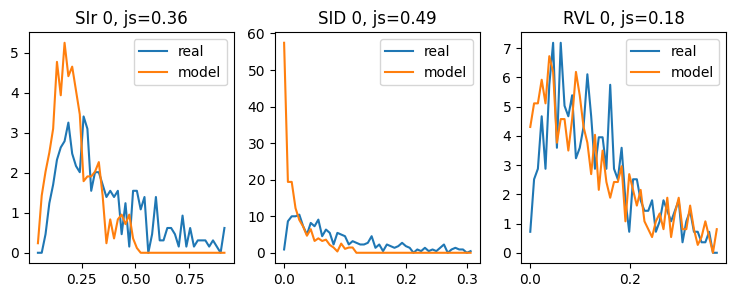

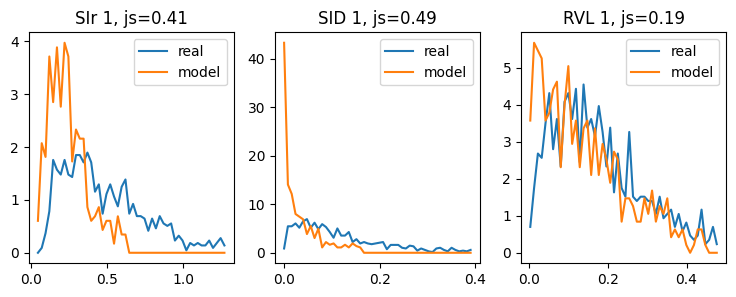

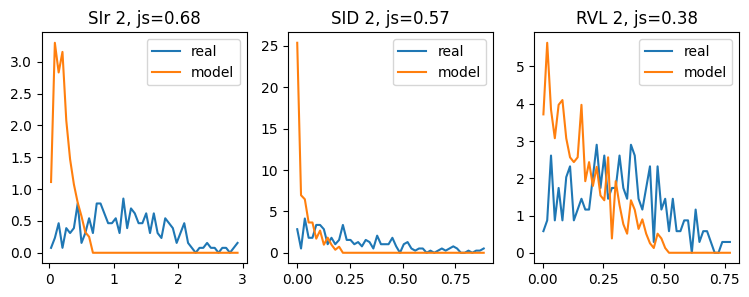

In [40]:
sir_js, fi_js, sid_js, rvl_js = [], [], [], []

n_bins = 50

for c in range(len(sir_real)):
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    sir_real_curr, sir_model_curr = sir_real[c], sir_model[c+1]
    if EXCLUDE_OUTLIERS:
        sir_real_curr = exclude_outliers_func(np.array(sir_real_curr).copy())
        sir_model_curr = exclude_outliers_func(sir_model_curr.copy())
    sir_min = min(min(sir_real_curr), min(sir_model_curr))
    sir_max = max(max(sir_real_curr), max(sir_model_curr))
    sir_real_pdf_curr, bins = np.histogram(sir_real_curr, bins=n_bins, range=(sir_min, sir_max), density=True)
    sir_model_pdf_curr, bins = np.histogram(sir_model_curr, bins=n_bins, range=(sir_min, sir_max), density=True)
    sir_js_curr = metric(sir_real_pdf_curr, sir_model_pdf_curr)
    sir_js.append(sir_js_curr)

    axs[0].set_title(f'SIr {c}, js={sir_js_curr:.2f}')
    axs[0].plot(bins[:-1], sir_real_pdf_curr, label='real')
    axs[0].plot(bins[:-1], sir_model_pdf_curr, label='model')
    axs[0].legend()
    
    sid_real_curr, sid_model_curr = sid_real[c], sid_model[c+1]
    if EXCLUDE_OUTLIERS:
        sid_real_curr = exclude_outliers_func(np.array(sid_real_curr).copy())
        sid_model_curr = exclude_outliers_func(sid_model_curr.copy())
    sid_min = min(min(sid_real_curr), min(sid_model_curr))
    sid_max = max(max(sid_real_curr), max(sid_model_curr))
    sid_real_pdf_curr, bins = np.histogram(sid_real_curr, bins=n_bins, range=(sid_min, sid_max), density=True)
    sid_model_pdf_curr, bins = np.histogram(sid_model_curr, bins=n_bins, range=(sid_min, sid_max), density=True)
    sid_js_curr = metric(sid_real_pdf_curr, sid_model_pdf_curr)
    sid_js.append(sid_js_curr)

    axs[1].set_title(f'SID {c}, js={sid_js_curr:.2f}')
    axs[1].plot(bins[:-1], sid_real_pdf_curr, label='real')
    axs[1].plot(bins[:-1], sid_model_pdf_curr, label='model')
    axs[1].legend()

    rvl_real_curr, rvl_model_curr = rvl_real[c], rvl_model[c+1]
    if EXCLUDE_OUTLIERS:
        rvl_real_curr = exclude_outliers_func(np.array(rvl_real_curr).copy())
        rvl_model_curr = exclude_outliers_func(rvl_model_curr.copy())
    rvl_min = min(min(rvl_real_curr), min(rvl_model_curr))
    rvl_max = max(max(rvl_real_curr), max(rvl_model_curr))
    rvl_real_pdf_curr, bins = np.histogram(rvl_real_curr, bins=n_bins, range=(rvl_min, rvl_max), density=True)
    rvl_model_pdf_curr, bins = np.histogram(rvl_model_curr, bins=n_bins, range=(rvl_min, rvl_max), density=True)
    rvl_js_curr = metric(rvl_real_pdf_curr, rvl_model_pdf_curr)
    rvl_js.append(rvl_js_curr)

    axs[2].set_title(f'RVL {c}, js={rvl_js_curr:.2f}')
    axs[2].plot(bins[:-1], rvl_real_pdf_curr, label='real')
    axs[2].plot(bins[:-1], rvl_model_pdf_curr, label='model')
    axs[2].legend()

    plt.show()


### Shuffle units

In [42]:
sir_js_shuffleu = {}
sid_js_shuffleu = {}
rvl_js_shuffleu = {}

for _ in range(10_000):
    sir_model_shuffle, sid_model_shuffle, rvl_model_shuffle = \
        shuffle_nested_lists(sir_model, sid_model, rvl_model)

    for c in range(len(sir_real)):
        if c not in sir_js_shuffleu.keys():
            sir_js_shuffleu[c] = []
            sid_js_shuffleu[c] = []
            rvl_js_shuffleu[c] = []

        sir_real_curr = sir_real[c]
        sir_model_curr = sir_model_shuffle[c+1]
        if EXCLUDE_OUTLIERS:
            sir_real_curr = exclude_outliers_func(np.array(sir_real_curr).copy())
            sir_model_curr = exclude_outliers_func(sir_model_curr.copy())
        sir_min = min(min(sir_real_curr), min(sir_model_curr))
        sir_max = max(max(sir_real_curr), max(sir_model_curr))
        sir_real_pdf_curr, bins = np.histogram(sir_real_curr, bins=n_bins, range=(sir_min, sir_max), density=True)
        sir_model_pdf_curr, bins = np.histogram(sir_model_curr, bins=n_bins, range=(sir_min, sir_max), density=True)
        sir_js_curr = metric(sir_real_pdf_curr, sir_model_pdf_curr)
        sir_js_shuffleu[c].append(sir_js_curr)
        
        sid_real_curr = sid_real[c]
        sid_model_curr = sid_model_shuffle[c+1]
        if EXCLUDE_OUTLIERS:
            sid_real_curr = exclude_outliers_func(np.array(sid_real_curr).copy())
            sid_model_curr = exclude_outliers_func(sid_model_curr.copy())
        sid_min = min(min(sid_real_curr), min(sid_model_curr))
        sid_max = max(max(sid_real_curr), max(sid_model_curr))
        sid_real_pdf_curr, bins = np.histogram(sid_real_curr, bins=n_bins, range=(sid_min, sid_max), density=True)
        sid_model_pdf_curr, bins = np.histogram(sid_model_curr, bins=n_bins, range=(sid_min, sid_max), density=True)
        sid_js_curr = metric(sid_real_pdf_curr, sid_model_pdf_curr)
        sid_js_shuffleu[c].append(sid_js_curr)

        rvl_real_curr = rvl_real[c]
        rvl_model_curr = rvl_model_shuffle[c+1]
        if EXCLUDE_OUTLIERS:
            rvl_real_curr = exclude_outliers_func(np.array(rvl_real_curr).copy())
            rvl_model_curr = exclude_outliers_func(rvl_model_curr.copy())
        rvl_min = min(min(rvl_real_curr), min(rvl_model_curr))
        rvl_max = max(max(rvl_real_curr), max(rvl_model_curr))
        rvl_real_pdf_curr, bins = np.histogram(rvl_real_curr, bins=n_bins, range=(rvl_min, rvl_max), density=True)
        rvl_model_pdf_curr, bins = np.histogram(rvl_model_curr, bins=n_bins, range=(rvl_min, rvl_max), density=True)
        rvl_js_curr = metric(rvl_real_pdf_curr, rvl_model_pdf_curr)
        rvl_js_shuffleu[c].append(rvl_js_curr)


### Print for development model

In [44]:
flatten = lambda xss: [x for xs in xss for x in xs]

In [45]:
from scipy import stats
EPS = 1e-10

def get_significance(js_shuffleu, js):
    pvalue, zscore, prank = {}, {}, {}

    for idx, c in enumerate(js_shuffleu.keys()):
        pvalue[c] = np.sum(js_shuffleu[c]<=js[idx])/len(js_shuffleu[c])
        pvalue[c] = EPS if pvalue[c] == 0 else pvalue[c]
        zscore[c] = (js[idx] - np.mean(js_shuffleu[c])) / np.std(js_shuffleu[c])
        prank[c] = stats.percentileofscore(js_shuffleu[c], js[idx])
    return pvalue, zscore, prank

def combine_pvalues(pvalue):
    pv = list(pvalue.values())
    chi2_stat = -2 * np.sum(np.log(pv))
    df = 2*len(pv)
    return 1-stats.chi2.cdf(chi2_stat, df)

def combine_zscores(zscore):
    c = np.sum(list(zscore.values())) / np.sqrt(len(zscore.values()))
    return stats.norm.cdf(c)

def get_pv_stars(pvalue):
    if pvalue <= 0.001:
        return '***'
    elif pvalue <= 0.01:
        return '**'
    elif pvalue <= 0.05:
        return '*'
    else:
        return 'ns'

def get_perc_stars(percentile):
    if percentile <= 0.05:
        return '***'
    elif percentile <= 0.5:
        return '**'
    elif percentile <= 2.5:
        return '*'
    else:
        return 'ns'

In [46]:
pranks = []

print("SIr distance")
pvalue, zscore, prank = get_significance(sir_js_shuffleu, sir_js)
sir_js_p = combine_pvalues(pvalue)
sir_js_zs_p = combine_zscores(zscore)
pranks += list(prank.values())
sir_js_perc = np.mean(list(prank.values()))
print("\tp-values:")
print('\t', [f"{pvalue[c]}" for c in sorted(pvalue.keys())], f": {sir_js_p} {get_pv_stars(sir_js_p)}")
print("\tz-scores:")
print('\t', [f"{zscore[c]:.2f}" for c in sorted(zscore.keys())], f": {sir_js_zs_p} {get_pv_stars(sir_js_zs_p)}")
print("\tpercentiles:")
print('\t', [f"{prank[c]}" for c in sorted(prank.keys())], f": {sir_js_perc} {get_perc_stars(sir_js_perc)}")
print()

print("SId distance")
pvalue, zscore, prank = get_significance(sid_js_shuffleu, sid_js)
sid_js_p = combine_pvalues(pvalue)
sid_js_zs_p = combine_zscores(zscore)
pranks += list(prank.values())
sid_js_perc = np.mean(list(prank.values()))
print("\tp-values:")
print('\t', [f"{pvalue[c]}" for c in sorted(pvalue.keys())], f": {sid_js_p} {get_pv_stars(sid_js_p)}")
print("\tz-scores:")
print('\t', [f"{zscore[c]:.2f}" for c in sorted(zscore.keys())], f": {sid_js_zs_p} {get_pv_stars(sid_js_zs_p)}")
print("\tpercentiles:")
print('\t', [f"{prank[c]}" for c in sorted(prank.keys())], f": {sid_js_perc} {get_perc_stars(sid_js_perc)}")
print()

print("RVL distance")
pvalue, zscore, prank = get_significance(rvl_js_shuffleu, rvl_js)
rvl_js_p = combine_pvalues(pvalue)
rvl_js_zs_p = combine_zscores(zscore)
pranks += list(prank.values())
rvl_js_perc = np.mean(list(prank.values()))
print("\tp-values:")
print('\t', [f"{pvalue[c]}" for c in sorted(pvalue.keys())], f": {rvl_js_p} {get_pv_stars(rvl_js_p)}")
print("\tz-scores:")
print('\t', [f"{zscore[c]:.2f}" for c in sorted(zscore.keys())], f": {rvl_js_zs_p} {get_pv_stars(rvl_js_zs_p)}")
print("\tpercentiles:")
print('\t', [f"{prank[c]}" for c in sorted(prank.keys())], f": {rvl_js_perc} {get_perc_stars(rvl_js_perc)}")
print()

print(f"overall percentile: {np.mean([pranks]):.2f} {get_perc_stars(np.mean(pranks))}")

SIr distance
	p-values:
	 ['0.4769', '1e-10', '1e-10'] : 0.0 ***
	z-scores:
	 ['-0.05', '-5.53', '-5.54'] : 6.869697282726738e-11 ***
	percentiles:
	 ['47.69', '0.0', '0.0'] : 15.896666666666667 ns

SId distance
	p-values:
	 ['0.0949', '1e-10', '1e-10'] : 0.0 ***
	z-scores:
	 ['-1.32', '-5.13', '-6.65'] : 1.9329961899541355e-14 ***
	percentiles:
	 ['9.49', '0.0', '0.0'] : 3.1633333333333336 ns

RVL distance
	p-values:
	 ['0.0202', '1e-10', '1e-10'] : 0.0 ***
	z-scores:
	 ['-2.10', '-5.30', '-6.83'] : 1.0387081878480465e-16 ***
	percentiles:
	 ['2.02', '0.0', '0.0'] : 0.6733333333333333 *

overall percentile: 6.58 ns


# Jonckheere–Terpstra test

In [48]:
import subprocess
import time
import pandas as pd

def print_trend_stats(stats_df, source='model'):
    jts = []
    w12s = []
    w23s = []
    for metric in ["SIr", "SId", "RVL"]:
        jonck_test = stats_df[(stats_df['metric']==metric) & (stats_df['source']==source)]['jonckheere_p'].values[0]
        w_12 = stats_df[(stats_df['metric']==metric) & (stats_df['source']==source)]['wilcox_1_2_p'].values[0]
        w_23 = stats_df[(stats_df['metric']==metric) & (stats_df['source']==source)]['wilcox_2_3_p'].values[0]
        print(f"   {metric}: JT {get_pv_stars(jonck_test)},\t1->2 {get_pv_stars(w_12)}, 2->3 {get_pv_stars(w_23)}")
        jts.append(jonck_test)
        w12s.append(w_12)
        w23s.append(w_23)
    return jts, w12s, w23s


In [49]:
# DEVELOPMENT
np.save('R_stats/data/g_real.npy', np.concatenate([[i+1]*len(s) for i, s in enumerate(sir_real)]))
np.save('R_stats/data/g_real_perc.npy', np.concatenate([[i+1]*len(s) for i, s in enumerate(pc_perc_real)]))
for n, d in zip(
    ['sir', 'sid', 'rvl', 'pc_perc', 'hdc_perc', 'phdc_perc'],
    [sir_real, sid_real, rvl_real, pc_perc_real, hdc_perc_real, phdc_perc_real]
):
    np.save(f'R_stats/data/{n}_real.npy', np.concatenate(d))

np.save('R_stats/data/g_model.npy', np.concatenate([[i+1]*len(s) for i, s in enumerate(sir_model[1:])]))
for n, d in zip(['sir', 'sid', 'rvl'], [sir_model[1:], sid_model[1:], rvl_model[1:]]):
    np.save(f'R_stats/data/{n}_model.npy', np.concatenate(d))

subprocess.run(['Rscript', 'R_stats/calculate_stats.r'])
time.sleep(2)
stats_dev = pd.read_csv('R_stats/stats_out.csv')

In [50]:
print("Real data")
print_trend_stats(stats_dev, source='real')

Real data
   SIr: JT ***,	1->2 ***, 2->3 ***
   SId: JT ***,	1->2 ***, 2->3 ***
   RVL: JT ***,	1->2 ***, 2->3 ***


([np.float64(0.0001), np.float64(0.0001), np.float64(0.0001)],
 [np.float64(4.7829259114936e-16),
  np.float64(9.55044917354829e-07),
  np.float64(8.59225582287344e-10)],
 [np.float64(1.3665929287253298e-49),
  np.float64(6.2213744383662905e-21),
  np.float64(1.58057294919807e-24)])

In [51]:
print("Development")
print_trend_stats(stats_dev)

Development
   SIr: JT **,	1->2 ***, 2->3 ns
   SId: JT ***,	1->2 **, 2->3 *
   RVL: JT ***,	1->2 **, 2->3 *


([np.float64(0.009), np.float64(0.0001), np.float64(0.0001)],
 [np.float64(0.0006099209266089),
  np.float64(0.0033207497730759),
  np.float64(0.0034367233046092)],
 [np.float64(0.841496438833106),
  np.float64(0.0231884052481665),
  np.float64(0.0343924763618735)])

In [52]:
# WITH GRID CELLS
np.save('R_stats/data/g_model.npy', np.concatenate([[i+1]*len(s) for i, s in enumerate(sir_model[1:])]))
for n, d in zip(['sir', 'sid', 'rvl'], [sir_model[1:-1]+[sir_model_gc], sid_model[1:-1]+[sid_model_gc], rvl_model[1:-1]+[rvl_model_gc]]):
    np.save(f'R_stats/data/{n}_model.npy', np.concatenate(d))

subprocess.run(['Rscript', 'R_stats/calculate_stats.r'])
time.sleep(2)
stats_dev_gc = pd.read_csv('R_stats/stats_out.csv')

In [53]:
print("Development with GC")
print_trend_stats(stats_dev_gc)

Development with GC
   SIr: JT ***,	1->2 ***, 2->3 ***
   SId: JT ***,	1->2 **, 2->3 ***
   RVL: JT ***,	1->2 **, 2->3 ***


([np.float64(0.0001), np.float64(0.0001), np.float64(0.0001)],
 [np.float64(0.0002033069755363),
  np.float64(0.0022138331820506),
  np.float64(0.0022911488697394)],
 [np.float64(1.06617521076345e-05),
  np.float64(1.26233220248435e-07),
  np.float64(2.53078706427275e-07)])

In [54]:
stats_compare = []
stats_gc_compare = []

for a in range(len(args_compare)):
    print(labels_compare[a])
    sir_model_curr = sir_compare[a]
    sid_model_curr = sid_compare[a]
    rvl_model_curr = rvl_compare[a]
    np.save('R_stats/data/g_model.npy', np.concatenate([[i+1]*len(s) for i, s in enumerate(sir_model_curr[1:])]))
    for n, d in zip(['sir', 'sid', 'rvl'], [sir_model_curr[1:], sid_model_curr[1:], rvl_model_curr[1:]]):
        np.save(f'R_stats/data/{n}_model.npy', np.concatenate(d))

    subprocess.run(['Rscript', 'R_stats/calculate_stats.r'])
    time.sleep(2)
    stats_compare.append(pd.read_csv('R_stats/stats_out.csv'))

    sir_model_curr_gc = sir_compare_gc[a]
    sid_model_curr_gc = sid_compare_gc[a]
    rvl_model_curr_gc = rvl_compare_gc[a]
    np.save('R_stats/data/g_model.npy', np.concatenate([[i+1]*len(s) for i, s in enumerate(sir_model_curr[1:])]))
    for n, d in zip(['sir', 'sid', 'rvl'], [sir_model_curr[1:-1]+[sir_model_curr_gc], sid_model_curr[1:-1]+[sid_model_curr_gc], rvl_model_curr[1:-1]+[rvl_model_curr_gc]]):
        np.save(f'R_stats/data/{n}_model.npy', np.concatenate(d))
    
    subprocess.run(['Rscript', 'R_stats/calculate_stats.r'])
    time.sleep(2)
    stats_gc_compare.append(pd.read_csv('R_stats/stats_out.csv'))

Development
Less hidden units
More hidden units
Train longer
Smaller input
Bigger input


In [56]:
for i, l in enumerate(labels_compare):
    print(l)
    print_trend_stats(stats_gc_compare[i])
    print()

Development
   SIr: JT ***,	1->2 ***, 2->3 ***
   SId: JT ***,	1->2 **, 2->3 ***
   RVL: JT ***,	1->2 **, 2->3 ***

Less hidden units
   SIr: JT ***,	1->2 *, 2->3 ***
   SId: JT ***,	1->2 *, 2->3 ***
   RVL: JT ***,	1->2 *, 2->3 ***

More hidden units
   SIr: JT ***,	1->2 ***, 2->3 ns
   SId: JT ***,	1->2 ***, 2->3 ***
   RVL: JT ***,	1->2 ***, 2->3 ***

Train longer
   SIr: JT ***,	1->2 ns, 2->3 ***
   SId: JT ***,	1->2 ***, 2->3 ***
   RVL: JT ***,	1->2 ***, 2->3 ***

Smaller input
   SIr: JT ***,	1->2 ***, 2->3 ns
   SId: JT ***,	1->2 ***, 2->3 ***
   RVL: JT ***,	1->2 ***, 2->3 ***

Bigger input
   SIr: JT ***,	1->2 **, 2->3 ***
   SId: JT ***,	1->2 **, 2->3 ***
   RVL: JT ***,	1->2 **, 2->3 ***



# Figure plotting

#### Functions

In [57]:

# Function to add Mann-Whitney U test stars between clusters
def add_mw_stars(ax, stars, ys, y_pos, y_pos_stars=None, is_exp=True):
    line_style = ':' if is_exp else '-'
    lw = 0.6 if is_exp else 0.4
    color = 'dimgray'
    if y_pos_stars is None : y_pos_stars=y_pos
    
    for i, s in enumerate(stars):
        # Draw bracket between clusters i and i+1
        x1, x2 = i+1, i+2
        
        # Draw the horizontal line
        ax.hlines(y_pos, x1, x2, linestyle=line_style, color=color, lw=lw, zorder=-10)
        
        # Draw the vertical lines
        ax.vlines([x1, x2], [ys[i], ys[i+1]], [y_pos, y_pos], linestyle=line_style, color=color, lw=lw, zorder=-10)
        
        # Add stars
        ax.text((x1+x2)/2, y_pos_stars, s, ha='center', va='bottom' if is_exp else 'top', fontsize=6)


In [58]:
%%capture
jts_model, w12s_model, w23s_model = print_trend_stats(stats_dev, source='model')
jts_gc_model, w12s_gc_model, w23s_gc_model = print_trend_stats(stats_dev_gc, source='model')
jts_real, w12s_real, w23s_real = print_trend_stats(stats_dev, source='real')

In [59]:
# Function to add Mann-Whitney U test stars between clusters
def add_mw_stars(ax, stars, ys):
    
    for i, (s, y) in enumerate(zip(stars, ys)):
        # Draw bracket between clusters i and i+1
        x1, x2 = i+1, i+2
        
        # Add stars
        ax.text((x1+x2)/2, sum(y)/2, s, ha='center', va='center', fontsize=6, zorder=10)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

def normalize_multiple_samples(model_samples, real_samples):
    """
    Normalize data with minmax normalization.
    
    Parameters:
    -----------
    model_samples : list of lists
        Each inner list contains samples for one step
    real_samples : list of lists  
        Each inner list contains samples for one step
    
    Returns:
    --------
    dict with original and normalized data + statistics
    """
    
    # Calculate original statistics
    model_means = [np.mean(samples) for samples in model_samples]
    real_means = [np.mean(samples) for samples in real_samples]
    model_se = [stats.sem(samples) for samples in model_samples]
    real_se = [stats.sem(samples) for samples in real_samples]
    
    results = {}
    results['original'] = {
        'model_means': model_means,
        'real_means': real_means,
        'model_se': model_se,
        'real_se': real_se
    }
    
    # Global min-max normalization
    model_all = np.concatenate(model_samples)
    real_all = np.concatenate(real_samples)
    
    mm_scaler_global_model = MinMaxScaler()
    mm_scaler_global_real = MinMaxScaler()
    
    model_all_mm = mm_scaler_global_model.fit_transform(model_all.reshape(-1, 1)).flatten()
    real_all_mm = mm_scaler_global_real.fit_transform(real_all.reshape(-1, 1)).flatten()
    
    # Reshape back
    n_samples_per_step = len(model_samples[0])
    model_mm_by_step = [model_all_mm[i*n_samples_per_step:(i+1)*n_samples_per_step] 
                        for i in range(len(model_samples))]
    real_mm_by_step = [real_all_mm[i*n_samples_per_step:(i+1)*n_samples_per_step] 
                        for i in range(len(real_samples))]
    
    model_mm_global_means = [np.mean(samples) for samples in model_mm_by_step]
    real_mm_global_means = [np.mean(samples) for samples in real_mm_by_step]
    model_mm_global_se = [stats.sem(samples) for samples in model_mm_by_step]
    real_mm_global_se = [stats.sem(samples) for samples in real_mm_by_step]
    
    results['minmax'] = {
        'model_means': model_mm_global_means,
        'real_means': real_mm_global_means,
        'model_se': model_mm_global_se,
        'real_se': real_mm_global_se,
        'model_samples': model_mm_by_step,
        'real_samples': real_mm_by_step
    }
    
    return results

def calculate_trend_correlations(model_data, real_data):
    """Calculate Pearson and Spearman correlations for trend similarity."""
    pearson_r, pearson_p = stats.pearsonr(model_data, real_data, alternative='greater')
    spearman_r, spearman_p = stats.spearmanr(model_data, real_data, alternative='greater')
    
    return {
        'pearson': {'r': pearson_r, 'p': pearson_p},
        'spearman': {'r': spearman_r, 'p': spearman_p}
    }


#### Plotting

In [ ]:
c_pc = '#C5268D' #E66405'
c_hd = '#428808' #40A269'
c_phd = '#3589EB' #095CE6'

ls_real = (0, (1,0.75))
ls_model = 'solid'

labels_plot = ['crawl', 'walk', 'run', 'adult']

In [ ]:
model_samples = sir_model + [sir_model_gc]
real_samples = [sir_model[0]] + sir_real + [sir_real[-1]]
sir_results = normalize_multiple_samples(model_samples, real_samples)

model_samples = sid_model + [sid_model_gc]
real_samples = [sid_model[0]] + sid_real + [sid_real[-1]]
sid_results = normalize_multiple_samples(model_samples, real_samples)

model_samples = rvl_model + [rvl_model_gc]
real_samples = [rvl_model[0]] + rvl_real + [rvl_real[-1]]
rvl_results = normalize_multiple_samples(model_samples, real_samples)

In [ ]:
sir_results_compare, sid_results_compare, rvl_results_compare = [], [], []

for idx, l in enumerate(labels_compare):
    model_samples = sir_compare[idx] + [sir_compare_gc[idx]]
    real_samples = [sir_compare[idx][0]] + sir_real + [sir_real[-1]]
    sir_results_compare.append(normalize_multiple_samples(model_samples, real_samples))

    model_samples = sid_compare[idx] + [sid_compare_gc[idx]]
    real_samples = [sid_compare[idx][0]] + sid_real + [sid_real[-1]]
    sid_results_compare.append(normalize_multiple_samples(model_samples, real_samples))

    model_samples = rvl_compare[idx] + [rvl_compare_gc[idx]]
    real_samples = [rvl_compare[idx][0]] + rvl_real + [rvl_real[-1]]
    rvl_results_compare.append(normalize_multiple_samples(model_samples, real_samples))

/home/USER/miniconda3/envs/vrtopc/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/USER/miniconda3/envs/vrtopc/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/USER/miniconda3/envs/vrtopc/lib/python3.9/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/USER/miniconda3/envs/vrtopc/lib/python3.9/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/USER/miniconda3/envs/vrtopc/lib/python3.9/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/USER/miniconda3/envs/vrtopc/lib/python3

In [65]:
alpha_low = 0.2

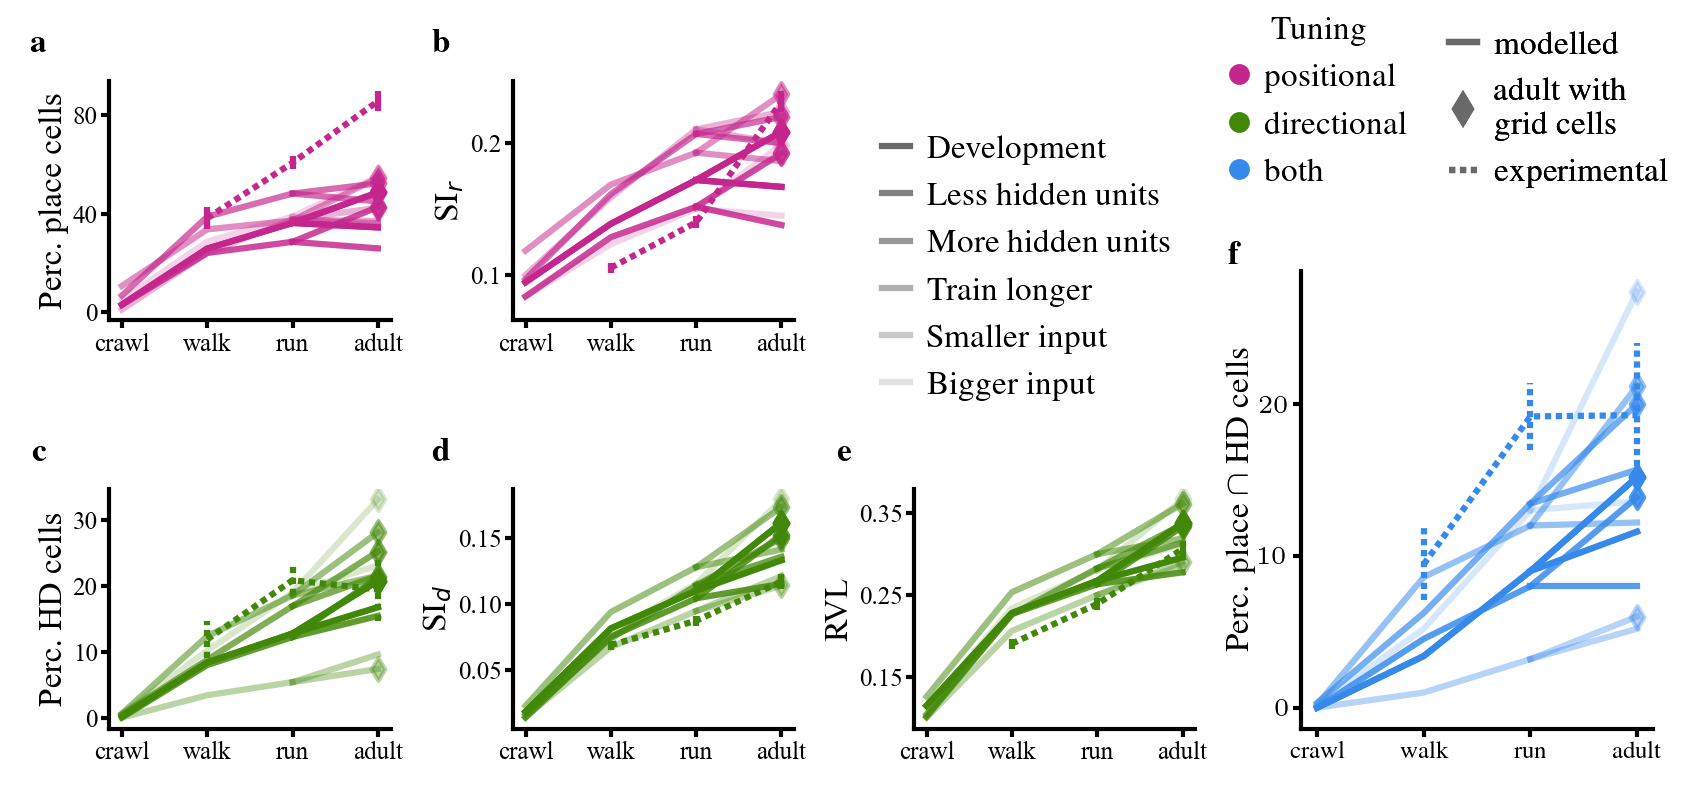

In [ ]:
import matplotlib.lines as mlines

plt.style.use(os.path.join(BASE_DIR, 'matplotlib_style.mplstyle'))

fig, axs = plt.subplots(2, 4, figsize=(5.5, 2.5), width_ratios=(1,1,1,1.25), dpi=300, layout="constrained")
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'
plt.rcParams['font.family'] = 'serif'

###############################################################
### PLOT 1 ####################################################
ax = axs.flat[0]

ax.annotate(
    r'\textbf{a}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 5), textcoords='offset points',
    ha='right', va='bottom'
)
ax.set_ylabel('Perc. place cells')

# Model
ax.plot(pc_perc_model[:-1], c=c_pc, label='Modeled', linestyle=ls_model)
ax.plot([2,3], pc_perc_model[-2:], c=c_pc, label='Modeled', linestyle=ls_model)
ax.scatter(3, pc_perc_model_gc, c=c_pc, marker='d', s=15)
ax.plot([2,3], [pc_perc_model[-2], pc_perc_model_gc], c=c_pc, alpha=1., linestyle=ls_model)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    ax.plot(pc_perc_compare[idx][:-1], c=c_pc, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.plot([2,3], pc_perc_compare[idx][-2:], c=c_pc, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.scatter(3, pc_perc_compare_gc[idx], c=c_pc, marker='d', s=15, alpha=alpha)
    ax.plot([2,3], [pc_perc_compare[idx][-2], pc_perc_compare_gc[idx]], c=c_pc, linestyle=ls_model, alpha=alpha)

# Real
m = [np.mean(y) for y in pc_perc_real]
sem = [np.std(y) / np.sqrt(len(y)) for y in pc_perc_real]
ax.plot(range(1, len(m)+1), m, c=c_pc, linestyle=ls_real, label='Experimental')
for i in range(len(m)):
    ax.errorbar(i+1, m[i], yerr=sem[i], fmt='none', linewidth=1.5, c=c_pc, linestyle=':', capsize=0, zorder=5)

ax.set_xticks(range(len(sir_model)), labels_plot)
ax.set_yticks([0, 40, 80])
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 2 ####################################################
ax = axs.flat[1]

ax.annotate(
    r'\textbf{b}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 5), textcoords='offset points',
    ha='right', va='bottom'
)
ax.set_ylabel(r'SI$_r$')

# Model
m_model = sir_results['minmax']['model_means']
sem = sir_results['minmax']['model_se']
ax.plot(m_model[:-2], c=c_pc, label='Modeled', linestyle=ls_model)
ax.plot([2,3], m_model[-3:-1], c=c_pc, label='Modeled', linestyle=ls_model)
ax.scatter(3, m_model[-1], c=c_pc, marker='d', s=15)
ax.plot([2,3], [m_model[-3], m_model[-1]], c=c_pc, linestyle=ls_model)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    m_model = sir_results_compare[idx]['minmax']['model_means']
    sem = sir_results_compare[idx]['minmax']['model_se']
    ax.plot(m_model[:-2], c=c_pc, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.plot([2,3], m_model[-3:-1], c=c_pc, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.scatter(3, m_model[-1], c=c_pc, marker='d', s=15, alpha=alpha)
    ax.plot([2,3], [m_model[-3], m_model[-1]], c=c_pc, linestyle=ls_model, alpha=alpha)

# Real
m_real = sir_results['minmax']['real_means'][1:-1]
sem = sir_results['minmax']['real_se'][1:-1]
ax.plot(range(1, len(m_real)+1), m_real, c=c_pc, linestyle=ls_real, label='Experimental')
for i in range(len(m_real)):
    ax.errorbar(i+1, m_real[i], yerr=sem[i], fmt='none', linewidth=1.5, c=c_pc, linestyle=':', capsize=0, zorder=5)

ax.set_xticks(range(len(labels_plot)), labels_plot)
ax.set_ylim(bottom=0.065)
ax.set_yticks([0.1, 0.2])
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 3 ####################################################
ax = axs.flat[2]

alphas = np.linspace(1, 0.2, len(labels_compare))
lines_legend = []
for idx, l in enumerate(labels_compare):
    lines_legend.append(
        mlines.Line2D([], [], color='dimgray', linestyle=ls_model, label=l, alpha=alphas[idx])
    )
legend1 = ax.legend(
    handles=lines_legend, title_fontsize=8,
    loc='upper center', ncol=1, frameon=False, handlelength=0.85, bbox_to_anchor=(0.4, 0.9), 
    fontsize=8, labelspacing=0.5, handletextpad=0.5, #borderpad=-0.5, 
)

ax.set_axis_off()


###############################################################
### PLOT 4 ####################################################
ax = axs.flat[4]
ax.annotate(
    r'\textbf{c}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 5), textcoords='offset points',
    ha='right', va='bottom'
)
ax.set_ylabel('Perc. HD cells')

# Model
ax.plot(hdc_perc_model[:-1], c=c_hd, label='Modeled', linestyle=ls_model)
ax.plot([2,3], hdc_perc_model[-2:], c=c_hd, label='Modeled', linestyle=ls_model, alpha=0.5)
ax.scatter(3, hdc_perc_model_gc, c=c_hd, marker='d', s=15)
ax.plot([2,3], [hdc_perc_model[-2], hdc_perc_model_gc], c=c_hd, linestyle=ls_model)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    ax.plot(hdc_perc_compare[idx][:-1], c=c_hd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.plot([2,3], hdc_perc_compare[idx][-2:], c=c_hd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.scatter(3, hdc_perc_compare_gc[idx], c=c_hd, marker='d', s=15, alpha=alpha)
    ax.plot([2,3], [hdc_perc_compare[idx][-2], hdc_perc_compare_gc[idx]], c=c_hd, linestyle=ls_model, alpha=alpha)

# Real
m = [np.mean(y) for y in hdc_perc_real]
sem = [np.std(y) / np.sqrt(len(y)) for y in hdc_perc_real]
ax.plot(range(1, len(m)+1), m, c=c_hd, linestyle=ls_real, label='Experimental')
for i in range(len(m)):
    eb = ax.errorbar(i+1, m[i], yerr=sem[i], fmt='none', linewidth=1.5, c=c_hd, linestyle=':', capsize=0, zorder=5)
    for blc in eb[2]:
        blc.set_linestyle(ls_real)

ax.set_xticks(range(len(labels_plot)), labels_plot)
# ax.set_yticks(np.arange(0, 31, 10))
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 5 ####################################################
ax = axs.flat[5]
ax.annotate(
    r'\textbf{d}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 5), textcoords='offset points',
    ha='right', va='bottom'
)
ax.set_ylabel(r'SI$_d$')

# Model
m_model = sid_results['minmax']['model_means']
sem = sid_results['minmax']['model_se']
ax.plot(m_model[:-2], c=c_hd, label='Modeled', linestyle=ls_model)
ax.plot([2,3], m_model[-3:-1], c=c_hd, label='Modeled', linestyle=ls_model, alpha=0.5)
ax.scatter(3, m_model[-1], c=c_hd, marker='d', s=15)
ax.plot([2,3], [m_model[-3], m_model[-1]], c=c_hd, alpha=1., linestyle=ls_model)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    m_model = sid_results_compare[idx]['minmax']['model_means']
    sem = sid_results_compare[idx]['minmax']['model_se']
    ax.plot(m_model[:-2], c=c_hd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.plot([2,3], m_model[-3:-1], c=c_hd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.scatter(3, m_model[-1], c=c_hd, marker='d', s=15, alpha=alpha)
    ax.plot([2,3], [m_model[-3], m_model[-1]], c=c_hd, linestyle=ls_model, alpha=alpha)

# Real
m_real = sid_results['minmax']['real_means'][1:-1]
sem = sid_results['minmax']['real_se'][1:-1]
ax.plot(range(1, len(m_real)+1), m_real, c=c_hd, linestyle=ls_real, label='Experimental')
for i in range(len(m_real)):
    ax.errorbar(i+1, m_real[i], yerr=sem[i], fmt='none', linewidth=1.5, c=c_hd, linestyle=':', capsize=0, zorder=5)

ax.set_xticks(range(len(labels_plot)), labels_plot)
ax.set_yticks([0.05, 0.1, 0.15])
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 6 ####################################################
ax = axs.flat[6]
ax.annotate(
    r'\textbf{e}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 5), textcoords='offset points',
    ha='right', va='bottom'
)
ax.set_ylabel('RVL')

# Model
m_model = rvl_results['minmax']['model_means']
sem = rvl_results['minmax']['model_se']
ax.plot(m_model[:-2], c=c_hd, label='Modeled', linestyle=ls_model)
ax.plot([2,3], m_model[-3:-1], c=c_hd, label='Modeled', linestyle=ls_model, alpha=0.5)
ax.scatter(3, m_model[-1], c=c_hd, marker='d', s=15)
ax.plot([2,3], [m_model[-3], m_model[-1]], c=c_hd, linestyle=ls_model)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    m_model = rvl_results_compare[idx]['minmax']['model_means']
    sem = rvl_results_compare[idx]['minmax']['model_se']
    ax.plot(m_model[:-2], c=c_hd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.plot([2,3], m_model[-3:-1], c=c_hd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax.scatter(3, m_model[-1], c=c_hd, marker='d', s=15, alpha=alpha)
    ax.plot([2,3], [m_model[-3], m_model[-1]], c=c_hd, linestyle=ls_model, alpha=alpha)

# Real
m_real = rvl_results['minmax']['real_means'][1:-1]
sem = rvl_results['minmax']['real_se'][1:-1]
ax.plot(range(1, len(m_real)+1), m_real, c=c_hd, linestyle=ls_real, label='Experimental')
for i in range(len(m_real)):
    ax.errorbar(i+1, m_real[i], yerr=sem[i], fmt='none', linewidth=1.5, c=c_hd, linestyle=':', capsize=0, zorder=5)

ax.set_xticks(range(len(labels_plot)), labels_plot)
ax.set_yticks([0.15, 0.25, 0.35])
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 4+8 ##################################################
gs = axs.flat[3].get_gridspec()
axs.flat[3].remove()
axs.flat[7].remove()

# Make a smaller axes for plot g (occupying lower part of the last column)
ax_g = fig.add_subplot(gs[:, -1])  # Get the full slot
ax_g.set_anchor('S')
ax_g.set_box_aspect(1.3)

# Plot as before
ax_g.annotate(
    r'\textbf{f}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 0), textcoords='offset points',
    ha='right', va='bottom'
)
ax_g.set_ylabel(r'Perc. place $\cap$ HD cells')

# Model
ax_g.plot(phdc_perc_model[:-1], c=c_phd, label='Modeled', linestyle=ls_model)
ax_g.plot([2,3], phdc_perc_model[-2:], c=c_phd, label='Modeled', linestyle=ls_model, alpha=0.5)
ax_g.scatter(3, phdc_perc_model_gc, c=c_phd, marker='d', s=15)
ax_g.plot([2,3], [phdc_perc_model[-2], phdc_perc_model_gc], c=c_phd, linestyle=ls_model)

for idx, alpha in enumerate(np.linspace(1, alpha_low, len(labels_compare))):
    ax_g.plot(phdc_perc_compare[idx][:-1], c=c_phd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax_g.plot([2,3], phdc_perc_compare[idx][-2:], c=c_phd, label='Modeled', linestyle=ls_model, alpha=alpha)
    ax_g.scatter(3, phdc_perc_compare_gc[idx], c=c_phd, marker='d', s=15, alpha=alpha)
    ax_g.plot([2,3], [phdc_perc_compare[idx][-2], phdc_perc_compare_gc[idx]], c=c_phd, linestyle=ls_model, alpha=alpha)

# Real
m = [np.mean(y) for y in phdc_perc_real]
sem = [np.std(y) / np.sqrt(len(y)) for y in phdc_perc_real]
ax_g.plot(range(1, len(m)+1), m, c=c_phd, linestyle=ls_real, label='Experimental')
for i in range(len(m)):
    eb = ax_g.errorbar(i+1, m[i], yerr=sem[i], fmt='none', linewidth=1.5, c=c_phd, capsize=0, zorder=5)
    for blc in eb[2]:
        blc.set_linestyle(ls_real)

ax_g.set_yticks([0, 10, 20])
ax_g.set_xticks(range(len(labels_plot)), labels_plot)
ax_g.spines[['right', 'top']].set_visible(False)

# ----------- Add Legends Above Plot g -----------------

# 2. Legend for positional/directional tuning (model colors)
pos_line = mlines.Line2D([], [], marker='o', markersize=4, linestyle='none', color=c_pc, label='positional')
dir_line = mlines.Line2D([], [], marker='o', markersize=4, linestyle='none', color=c_hd, label='directional')
both_line = mlines.Line2D([], [], marker='o', markersize=4, linestyle='none', color=c_phd, label='both')
legend2 = ax_g.legend(
    handles=[pos_line, dir_line, both_line], title='Tuning', title_fontsize=8,
    loc='upper center', bbox_to_anchor=(0.05, 1.60), ncol=1, frameon=False, handlelength=0.5,
    fontsize=8, borderpad=0.1, labelspacing=0.5, handletextpad=0.5
)

# 1. Legend for modeled/experimental (gray lines)
modeled_line = mlines.Line2D([], [], color='dimgray', linestyle=ls_model, label='modelled')
adult_withgc_line = mlines.Line2D([], [], marker='d', color='dimgray', linestyle='none', label='adult with\ngrid cells', markersize=5)
experimental_line = mlines.Line2D([], [], color='dimgray', linestyle=ls_real, label='experimental')
legend1 = ax_g.legend(
    handles=[modeled_line, adult_withgc_line, experimental_line], title_fontsize=8,
    loc='upper center', bbox_to_anchor=(0.73, 1.57), ncol=1, frameon=False, handlelength=0.85,
    fontsize=8, borderpad=0.1, labelspacing=0.5, handletextpad=0.5
)

# # Add both legends to the axes
ax_g.add_artist(legend1)
ax_g.add_artist(legend2)


fig.get_layout_engine().set(h_pad=0.025, w_pad=0.03) #, hspace=0, wspace=0)

title = f'figure_develop_min_max_global'
# plt.savefig(
#     os.path.join(BASE_DIR, 'paper_figures', f'{title}_parameter_sweep.pdf'),
#     dpi=300, bbox_inches='tight', pad_inches=0.04
# )
plt.show()

# Calculate deviation percentages

In [67]:
labels_compare

['Development',
 'Less hidden units',
 'More hidden units',
 'Train longer',
 'Smaller input',
 'Bigger input']

In [68]:
from scipy.stats import wasserstein_distance

def calculate_distances(data_dev, data_compare):
    dist_perc, dist_perc_mean = [], []
    std_dist_perc, std_dist_perc_mean = [], []
    wass_dist_perc, wass_dist_perc_mean = [], []
    for idx, l in enumerate(labels_compare):
        print(l)
        dist_perc = [np.abs(dev.mean() - comp.mean()) / dev.mean()*100 for dev, comp in zip(data_dev, data_compare[idx])]
        dist_perc_mean = np.mean(dist_perc)
        std_dist_perc = [np.abs(dev.std() - comp.std()) / dev.std()*100 for dev, comp in zip(data_dev, data_compare[idx])]
        std_dist_perc_mean = np.mean(std_dist_perc)
        wass_dist_perc = [wasserstein_distance(dev, comp) / dev.mean() * 100 for dev, comp in zip(data_dev, data_compare[idx])]
        wass_dist_perc_mean = np.mean(wass_dist_perc)

        print(f"Distance:", [f"{d:.0f}" for d in dist_perc], f"{dist_perc_mean:.0f}%")
        print(f"Std distance:", [f"{d:.0f}" for d in std_dist_perc], f"{std_dist_perc_mean:.0f}%")
        print(f"Wasserstein distance:", [f"{d:.0f}" for d in wass_dist_perc], f"{wass_dist_perc_mean:.0f}%")
        print()
    
    return dist_perc, dist_perc_mean, std_dist_perc, std_dist_perc_mean, wass_dist_perc, wass_dist_perc_mean


def calculate_distances_gc(data_dev, data_compare, data_compare_gc):
    dist_perc, dist_perc_mean = [], []
    std_dist_perc, std_dist_perc_mean = [], []
    wass_dist_perc, wass_dist_perc_mean = [], []
    for idx, l in enumerate(labels_compare):
        print(l)
        d_comp_gc = data_compare[idx][:-1]+[data_compare_gc[idx]]
        dist_perc = [np.abs(dev.mean() - comp.mean()) / dev.mean()*100 for dev, comp in zip(data_dev, d_comp_gc)]
        dist_perc_mean = np.mean(dist_perc)
        std_dist_perc = [np.abs(dev.std() - comp.std()) / dev.std()*100 for dev, comp in zip(data_dev, d_comp_gc)]
        std_dist_perc_mean = np.mean(std_dist_perc)
        wass_dist_perc = [wasserstein_distance(dev, comp) / dev.mean() * 100 for dev, comp in zip(data_dev, d_comp_gc)]
        wass_dist_perc_mean = np.mean(wass_dist_perc)

        print(f"Distance:", [f"{d:.0f}" for d in dist_perc], f"{dist_perc_mean:.0f}%")
        print(f"Std distance:", [f"{d:.0f}" for d in std_dist_perc], f"{std_dist_perc_mean:.0f}%")
        print(f"Wasserstein distance:", [f"{d:.0f}" for d in wass_dist_perc], f"{wass_dist_perc_mean:.0f}%")
        print()
    
    return dist_perc, dist_perc_mean, std_dist_perc, std_dist_perc_mean, wass_dist_perc, wass_dist_perc_mean

In [69]:
calculate_distances_gc(rvl_model[:-1]+[rvl_model_gc], rvl_compare, rvl_compare_gc)

Development
Distance: ['0', '0', '0', '0'] 0%
Std distance: ['0', '0', '0', '0'] 0%
Wasserstein distance: ['0', '0', '0', '0'] 0%

Less hidden units
Distance: ['11', '1', '0', '0'] 3%
Std distance: ['9', '2', '2', '1'] 3%
Wasserstein distance: ['11', '5', '6', '3'] 6%

More hidden units
Distance: ['1', '9', '17', '10'] 9%
Std distance: ['11', '1', '8', '3'] 6%
Wasserstein distance: ['5', '10', '17', '10'] 10%

Train longer
Distance: ['18', '19', '20', '15'] 18%
Std distance: ['23', '10', '9', '5'] 12%
Wasserstein distance: ['18', '19', '20', '15'] 18%

Smaller input
Distance: ['22', '19', '16', '23'] 20%
Std distance: ['19', '17', '18', '27'] 20%
Wasserstein distance: ['22', '19', '17', '23'] 20%

Bigger input
Distance: ['10', '15', '17', '21'] 16%
Std distance: ['15', '8', '15', '16'] 13%
Wasserstein distance: ['10', '15', '17', '21'] 16%



([np.float64(9.72491408709972),
  np.float64(14.693779682443212),
  np.float64(17.362068309527988),
  np.float64(21.364860768757598)],
 np.float64(15.78640571195713),
 [np.float64(14.680728727661357),
  np.float64(7.569622204397362),
  np.float64(15.151317974926586),
  np.float64(15.780366274823985)],
 np.float64(13.295508795452323),
 [np.float64(10.086771985851838),
  np.float64(14.700827983971246),
  np.float64(17.39033865319052),
  np.float64(21.364860768757595)],
 np.float64(15.8856998479428))

In [70]:
for idx, l in enumerate(labels_compare):
        print(l)
        dist_perc = [np.abs(dev - comp) for dev, comp in zip(phdc_perc_model[:-1]+[phdc_perc_model_gc], phdc_perc_compare[idx][:-1]+[phdc_perc_compare_gc[idx]])]
        dist_perc_mean = np.mean(dist_perc)

        print(f"Distance:", [f"{d:.0f}" for d in dist_perc], f"{dist_perc_mean:.0f}%")
        print()

Development
Distance: ['0', '0', '0', '0'] 0%

Less hidden units
Distance: ['0', '1', '1', '1'] 1%

More hidden units
Distance: ['0', '3', '4', '5'] 3%

Train longer
Distance: ['0', '5', '3', '6'] 4%

Smaller input
Distance: ['0', '2', '6', '9'] 4%

Bigger input
Distance: ['0', '2', '4', '12'] 5%



# End